# Act 4 - Khuyến mãi chạy vào vùng rủi ro tồn kho

**Câu hỏi trung tâm:** Khuyến mãi có đang được kích hoạt trong giai đoạn ngành hàng có mức sẵn sàng tồn kho yếu không?

Phân tích tập trung vào giao điểm giữa lịch khuyến mãi và tồn kho yếu ở cấp chương trình x ngành hàng x tháng.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


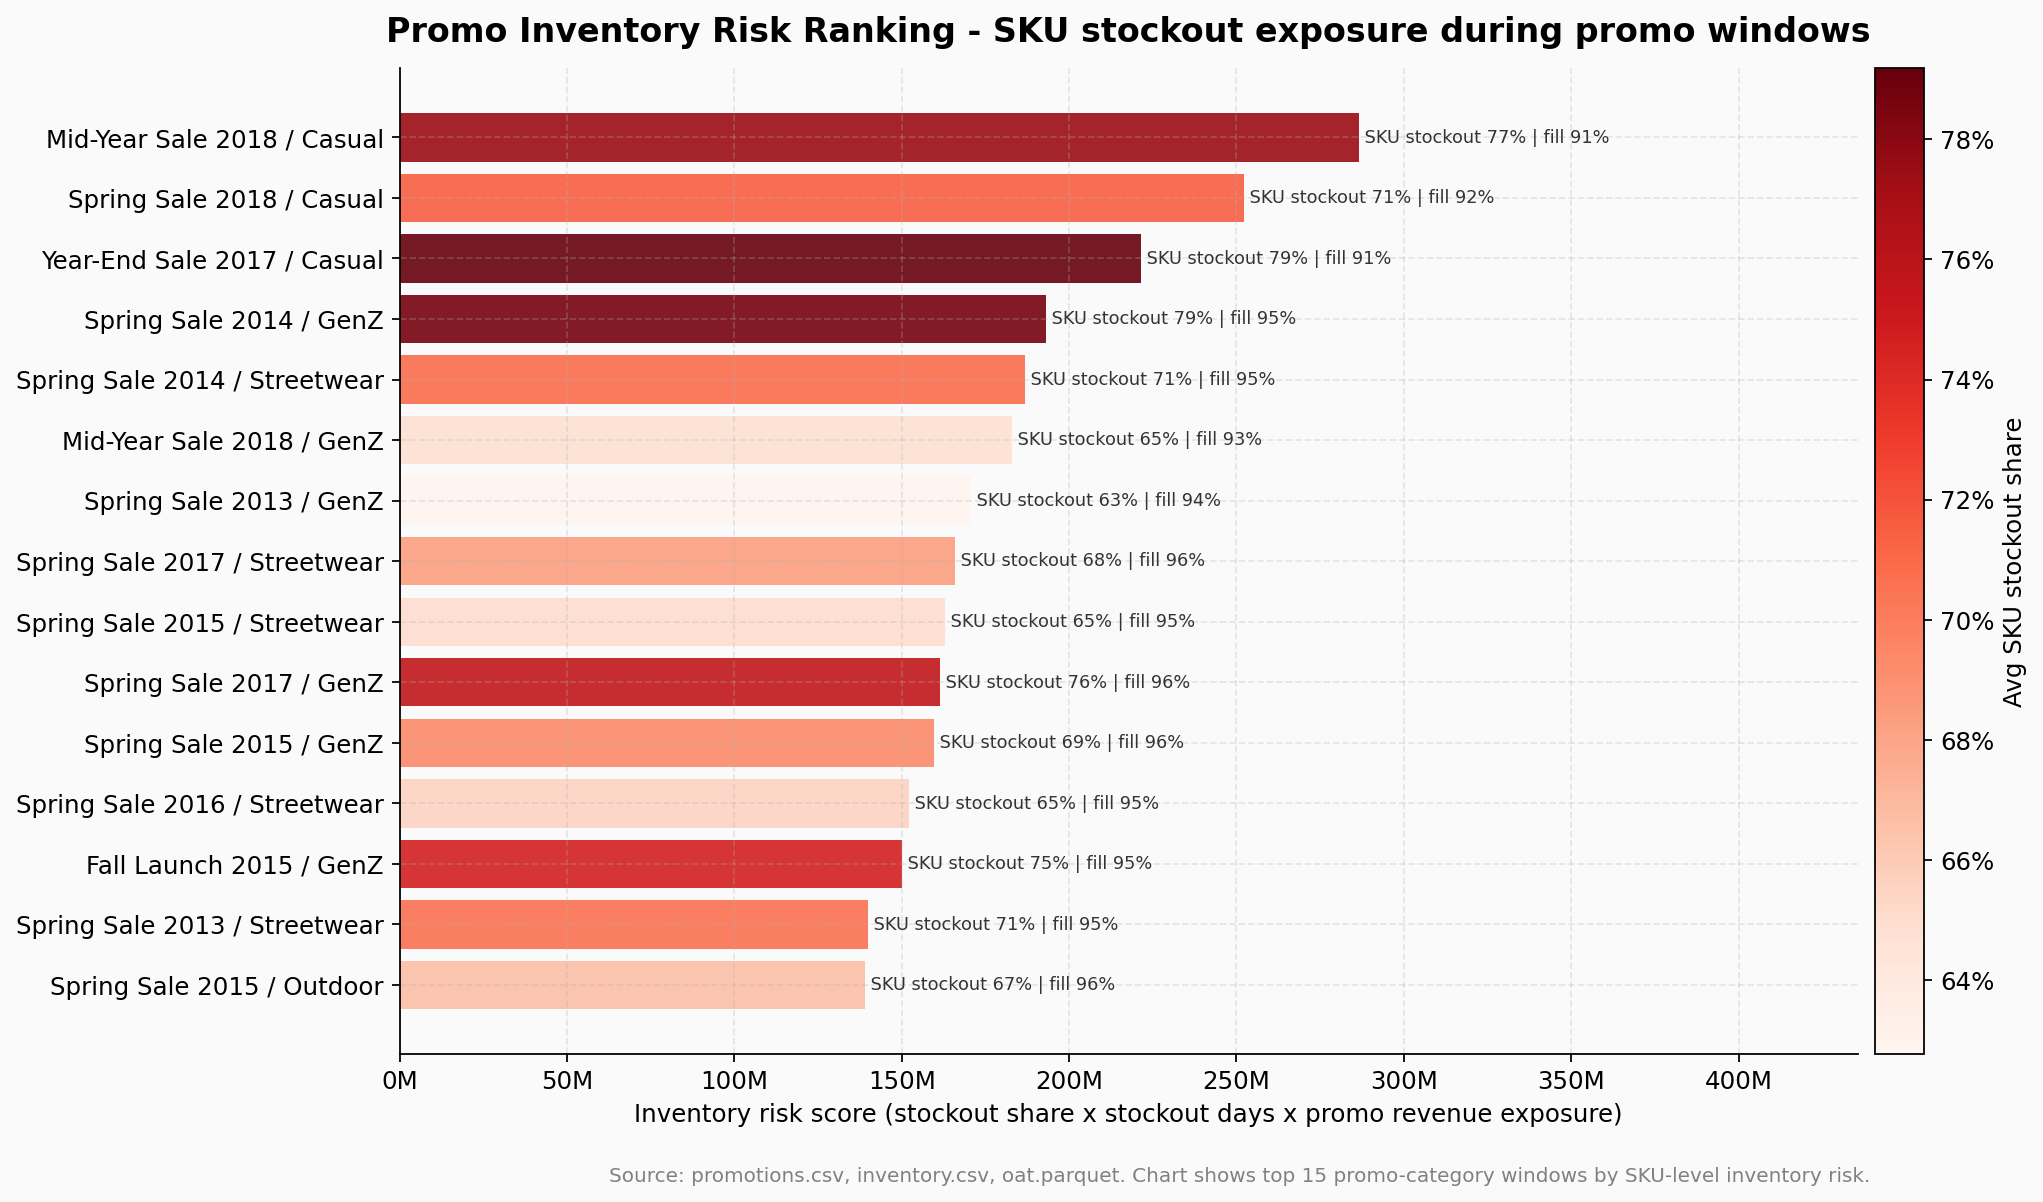

In [2]:
display(Image(str(CHARTS / "chart6_promo_inventory_risk.png"), width=950))


In [3]:
overlaps = pd.read_csv(TABLES / "promo_stockout_overlaps.csv")
risk = pd.read_csv(TABLES / "promo_inventory_risk_table.csv")
print(f"Số event chồng lấn: {len(overlaps)}")
print(f"Số chương trình bị ảnh hưởng: {overlaps['promo_id'].nunique()}")
print(f"Ngành hàng bị ảnh hưởng: {sorted(overlaps['category'].unique().tolist())}")
print(f"Tỷ lệ SKU thiếu hàng trung bình: {overlaps['stockout_product_share'].mean():.1%}")
print(f"Tỷ lệ đáp ứng đơn trung bình: {overlaps['avg_fill_rate'].mean():.1%}")
print(f"Lợi nhuận gộp ước tính bị mất: {overlaps['estimated_lost_gp'].sum():,.0f} VND")
risk_display = risk.head(20).rename(columns={
    "promo_id": "ma_khuyen_mai",
    "promo_name": "ten_khuyen_mai",
    "category": "nganh_hang",
    "overlap_months": "so_thang_chong_lan",
    "avg_sku_stockout_share": "ty_le_sku_thieu_hang_tb",
    "avg_fill_rate": "ty_le_dap_ung_don_tb",
    "estimated_lost_gp": "loi_nhuan_gop_uoc_tinh_mat",
    "promo_gp_contribution": "dong_gop_loi_nhuan_gop",
    "promo_net_revenue": "doanh_thu_thuan_khuyen_mai",
    "inventory_risk_score": "diem_rui_ro_ton_kho",
})
display(risk_display)


Số event chồng lấn: 426
Số chương trình bị ảnh hưởng: 50
Ngành hàng bị ảnh hưởng: ['Casual', 'GenZ', 'Outdoor', 'Streetwear']
Tỷ lệ SKU thiếu hàng trung bình: 67.5%
Tỷ lệ đáp ứng đơn trung bình: 96.2%
Lợi nhuận gộp ước tính bị mất: 23,547,465 VND


,ma_khuyen_mai,ten_khuyen_mai,nganh_hang,so_thang_chong_lan,ty_le_sku_thieu_hang_tb,max_sku_stockout_share,avg_stockout_days,max_stockout_days,ty_le_dap_ung_don_tb,min_fill_rate,loi_nhuan_gop_uoc_tinh_mat,dong_gop_loi_nhuan_gop,doanh_thu_thuan_khuyen_mai,negative_gp_exposure,diem_rui_ro_ton_kho
0,PROMO-0028,Mid-Year Sale 2018,Casual,2,0.774194,0.870968,2.629032,22,0.912366,0.2667,7.932671e+04,-3.028329e+07,1.407959e+08,3.028329e+07,2.865731e+08
1,PROMO-0027,Spring Sale 2018,Casual,2,0.714683,0.774194,2.369855,18,0.921008,0.4000,2.473240e+04,-8.596910e+06,1.489566e+08,8.596910e+06,2.522871e+08
2,PROMO-0024,Year-End Sale 2017,Casual,3,0.791795,0.846154,2.805128,19,0.906494,0.3667,3.386859e+04,-2.743982e+07,9.974252e+07,2.743982e+07,2.215367e+08
3,PROMO-0007,Spring Sale 2014,GenZ,2,0.786718,0.814815,1.508940,10,0.949701,0.6667,1.159950e+04,-1.246593e+07,1.626504e+08,1.246593e+07,1.930839e+08
4,PROMO-0007,Spring Sale 2014,Streetwear,2,0.708615,0.731183,1.620530,28,0.945981,0.0667,5.748829e+05,-1.246593e+07,1.626504e+08,1.246593e+07,1.867765e+08
5,PROMO-0028,Mid-Year Sale 2018,GenZ,2,0.647969,0.659574,2.003868,17,0.933203,0.4333,1.000183e+05,-3.028329e+07,1.407959e+08,3.028329e+07,1.828157e+08
6,PROMO-0001,Spring Sale 2013,GenZ,2,0.627706,0.636364,1.906926,23,0.936437,0.2333,1.284082e+04,-8.785409e+06,1.426156e+08,8.785409e+06,1.707092e+08
7,PROMO-0021,Spring Sale 2017,Streetwear,2,0.683382,0.728302,1.349492,22,0.955017,0.2667,4.351671e+05,-1.211826e+07,1.797860e+08,1.211826e+07,1.658019e+08
8,PROMO-0011,Spring Sale 2015,Streetwear,2,0.650025,0.699275,1.421343,25,0.952622,0.1667,5.584992e+05,-1.035161e+07,1.762220e+08,1.035161e+07,1.628130e+08
9,PROMO-0021,Spring Sale 2017,GenZ,2,0.756536,0.777778,1.186275,2,0.960454,0.9333,4.740742e+03,-1.211826e+07,1.797860e+08,1.211826e+07,1.613507e+08


## Phân tích

Sau khi xử lý đúng `applicable_category = null` là khuyến mãi áp dụng cho **tất cả ngành hàng**, có **426 điểm chồng lấn** ở cấp **chương trình x ngành hàng x tháng**, trải trên **50 chương trình** và 4 ngành hàng: **Casual, GenZ, Outdoor, Streetwear**.

Tỷ lệ đáp ứng đơn trung bình trong các tháng chồng lấn là **96.2%**, nên đây không phải thất bại tồn kho toàn ngành hàng. Điểm rủi ro nằm ở cấp SKU: trung bình **67.5% SKU trong ngành hàng có `stockout_flag = 1`** trong các tháng khuyến mãi chồng lấn.

Bảng xếp hạng rủi ro cho thấy cặp chương trình-ngành hàng rủi ro cao nhất là **Mid-Year Sale 2018 / Casual**, với điểm rủi ro **286,573,111**. Lợi nhuận gộp ước tính bị mất từ các điểm chồng lấn là **23,547,465 VND**.

**Kết luận Act 4:** Cần cổng kiểm tra tồn kho trước khi chạy khuyến mãi. Cổng này nên kiểm tra tỷ lệ SKU thiếu hàng và mức sẵn sàng của ngành hàng, không chỉ nhìn tỷ lệ đáp ứng đơn tổng hợp.
